In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error


In [2]:
df = pd.read_csv('ai 2020.csv')

In [3]:
df_processed = df.drop(['UDI', 'Product ID', 'Type'], axis=1)

In [4]:
df_processed = df.drop(['UDI', 'Product ID', 'Type'], axis=1)
df_processed['Power'] = df_processed['Torque [Nm]'] * df_processed['Rotational speed [rpm]']
df_processed['Temp_Diff'] = df_processed['Process temperature [K]'] - df_processed['Air temperature [K]']

In [5]:
x = df_processed.drop('Machine failure', axis=1)
y = df_processed['Machine failure']

In [6]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [10]:
scaler = MinMaxScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [12]:
model = RandomForestClassifier(random_state=42, class_weight='balanced')

In [13]:
model.fit(x_train_scaled, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [14]:
y_pred = model.predict(x_test_scaled)

In [15]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1939
           1       1.00      0.97      0.98        61

    accuracy                           1.00      2000
   macro avg       1.00      0.98      0.99      2000
weighted avg       1.00      1.00      1.00      2000



Grafik 'feature_importance.png' olarak kaydedildi.


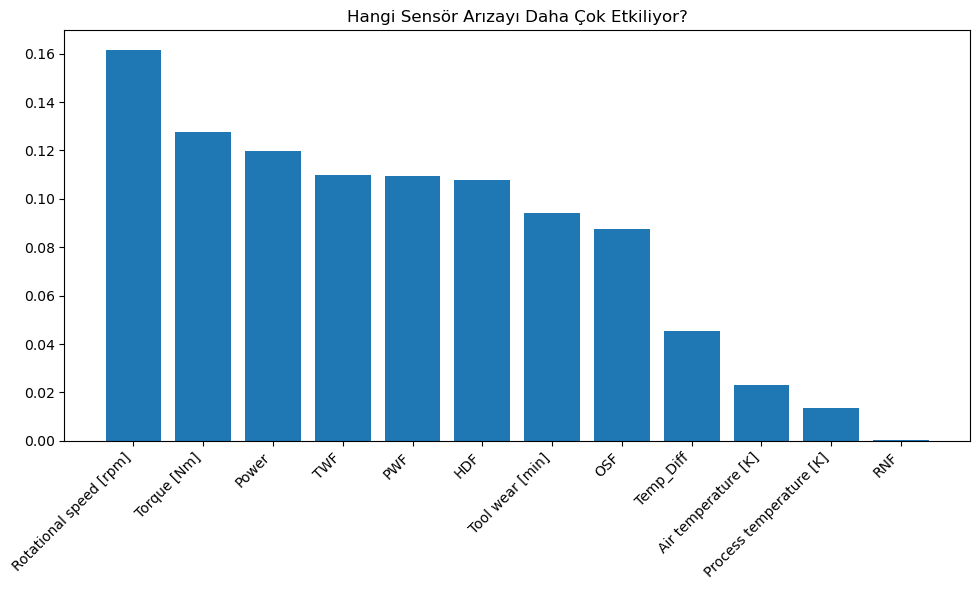

In [18]:
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = x.columns

plt.figure(figsize=(10, 6))
plt.title("Hangi Sensör Arızayı Daha Çok Etkiliyor?")
plt.bar(range(x.shape[1]), importances[indices], align="center")
plt.xticks(range(x.shape[1]), [feature_names[i] for i in indices], rotation=45, ha='right')
plt.tight_layout()
plt.savefig('feature_importance.png')
print("Grafik 'feature_importance.png' olarak kaydedildi.")

In [19]:
max_wear = df_processed['Tool wear [min]'].max()
df_processed['RUL'] = max_wear - df_processed['Tool wear [min]']

In [20]:
x_reg = df_processed.drop(['Machine failure', 'RUL', 'Tool wear [min]', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'], axis=1)
y_reg = df_processed['RUL']

In [21]:
x_train_r, x_test_r, y_train_r, y_test_r = train_test_split(x_reg, y_reg, test_size=0.2, random_state=42)

In [32]:
rul_model = RandomForestRegressor(random_state=42)
rul_model.fit(x_train_r, y_train_r)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [33]:
y_pred_r = rul_model.predict(x_test_r)
mae = mean_absolute_error(y_test_r, y_pred_r)

In [34]:
print(f"\n--- RUL (Remaining Useful Life) Prediction Results ---")
print(f"Mean Absolute Error (in minutes): {mae:.2f}")


--- RUL (Remaining Useful Life) Prediction Results ---
Mean Absolute Error (in minutes): 50.87
